In [2]:
import pandas as pd

# Path to the CSV file
naptan_path = r"C:\Users\Nineli.Lashkarashvil\SperryRail\Innovation\data_science\CPD\safe_route_finder\traffic_flow\Stops.csv"

# Load the CSV file into a DataFrame
naptan_df = pd.read_csv(naptan_path)

# Count the number of null values in each column
naptan_columns = ["NaptanCode", "Longitude", "Latitude", "ParentLocalityName", "LocalityName" ]
naptan_df = naptan_df[~(naptan_df['NaptanCode'].isnull()) & (naptan_df['Status']=="active")].reset_index(drop=True)
naptan_df = naptan_df[(naptan_df['ParentLocalityName'].isin(["London", "City of London"]))][naptan_columns]
# Print the count of null values for each column


C:\Users\Nineli.Lashkarashvil\AppData\Local\Temp\ipykernel_20108\894775318.py:7: DtypeWarning: Columns (1,2,6,8,21,22,23,24,25) have mixed types. Specify dtype option on import or set low_memory=False.
  naptan_df = pd.read_csv(naptan_path)


In [36]:
import geopandas as gpd
from shapely.geometry import Point
import pandas
lsoa_file = "C:\\Users\\Nineli.Lashkarashvil\\SperryRail\\Innovation\\data_science\\CPD\\safe_route_finder\\lsoa_geojson_map.geojson"
lsoa_gdf = gpd.read_file(lsoa_file)
# Ensure LSOA data is in EPSG:27700
if lsoa_gdf.crs != "EPSG:4326":
    lsoa_gdf = lsoa_gdf.to_crs("EPSG:4326")

lat = 697981.275945392 
lon = 5712323.2162685655
point = gpd.points_from_xy( [lon], [lat], crs=lsoa_gdf.crs)
# Simply iterate through all LSOA polygons
for _, row in lsoa_gdf.iterrows():
    if row.geometry.contains(point):
        print(row['LSOA11CD'])

In [37]:
lsoa_gdf

,LSOA11CD,LSOA11NM,MSOA11CD,MSOA11NM,LAD11CD,LAD11NM,RGN11CD,RGN11NM,UsualRes,HholdRes,ComEstRes,PopDen,Hholds,AvHholdSz,geometry
0,E01000001,City of London 001A,E02000001,City of London 001,E09000001,City of London,E12000007,London,1465,1465,0,112.9,876,1.7,"POLYGON ((-0.09729 51.52158, -0.09652 51.52027..."
1,E01000002,City of London 001B,E02000001,City of London 001,E09000001,City of London,E12000007,London,1436,1436,0,62.9,830,1.7,"POLYGON ((-0.08813 51.51941, -0.08929 51.51752..."
2,E01000003,City of London 001C,E02000001,City of London 001,E09000001,City of London,E12000007,London,1346,1250,96,227.7,817,1.5,"POLYGON ((-0.09679 51.52325, -0.09647 51.52282..."
3,E01000005,City of London 001E,E02000001,City of London 001,E09000001,City of London,E12000007,London,985,985,0,52.0,467,2.1,"POLYGON ((-0.07323 51.51, -0.07553 51.50974, -..."
4,E01000006,Barking and Dagenham 016A,E02000017,Barking and Dagenham 016,E09000002,Barking and Dagenham,E12000007,London,1703,1699,4,116.2,543,3.1,"POLYGON ((0.09115 51.53909, 0.09326 51.53787, ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4830,E01033742,Greenwich 007F,E02000319,Greenwich 007,E09000011,Greenwich,E12000007,London,1352,1352,0,107.6,581,2.3,"POLYGON ((0.0824 51.49886, 0.08415 51.49803, 0..."
4831,E01033743,Greenwich 002H,E02000314,Greenwich 002,E09000011,Greenwich,E12000007,London,2038,2038,0,20.4,663,3.1,"POLYGON ((0.11081 51.5098, 0.11227 51.50782, 0..."
4832,E01033744,Greenwich 007G,E02000319,Greenwich 007,E09000011,Greenwich,E12000007,London,1845,1728,117,125.8,646,2.7,"POLYGON ((0.08072 51.4955, 0.08165 51.49491, 0..."
4833,E01033745,Greenwich 002I,E02000314,Greenwich 002,E09000011,Greenwich,E12000007,London,1820,1820,0,32.3,591,3.1,"POLYGON ((0.10806 51.50135, 0.10664 51.50021, ..."


In [3]:
naptan_df

,NaptanCode,Longitude,Latitude,ParentLocalityName,LocalityName
75901,esxjgjtg,0.114130,51.618835,London,Chigwell Row
75902,esxjgjtj,0.113994,51.619323,London,Chigwell Row
79939,esxatmdm,0.102327,51.616943,London,Chigwell Row
223827,surgtmja,-0.313851,51.385732,London,Surbiton
225563,suragtdg,-0.327258,51.382210,London,Long Ditton
...,...,...,...,...,...
299817,76977,-0.127800,51.480630,London,Nine Elms
299818,75595,-0.111320,51.535520,London,Pentonville
299819,92689,-0.024680,51.437050,London,Bellingham
299820,92687,-0.022510,51.440150,London,Catford


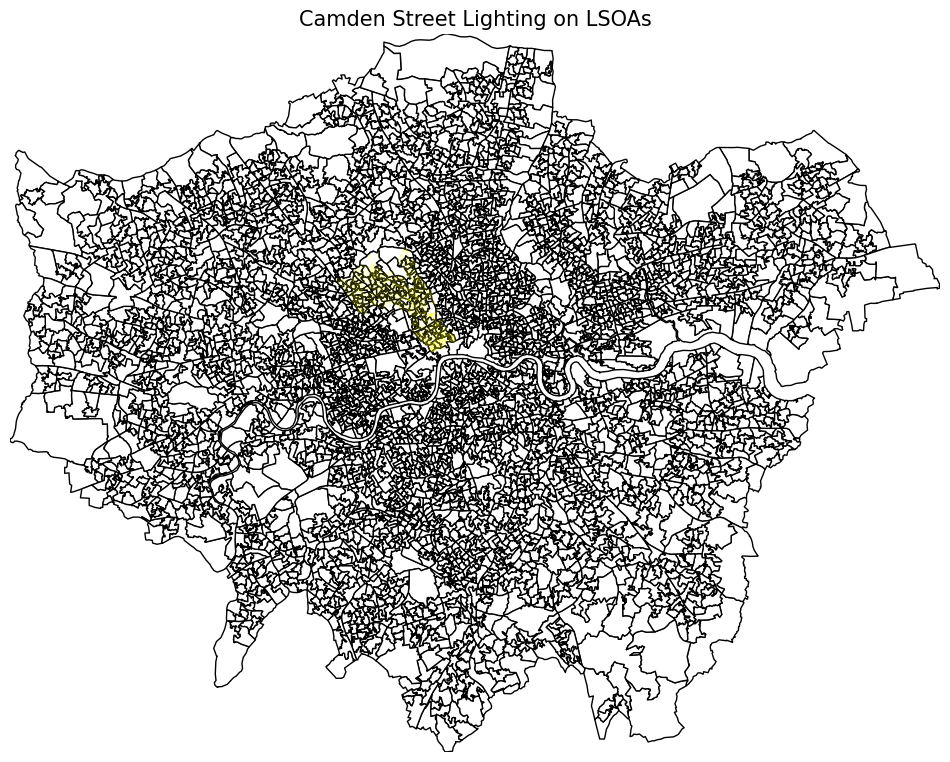

In [23]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point

def plot_street_lights_on_lsoas(street_lights_file, lsoa_boundaries_file):
    # Read the street lights CSV file
    street_lights_df = pd.read_csv(street_lights_file)
    
    # Ensure the latitude and longitude columns are correct
    assert 'Latitude' in street_lights_df.columns, "Latitude column not found in the CSV file"
    assert 'Longitude' in street_lights_df.columns, "Longitude column not found in the CSV file"
    
    # Create a GeoDataFrame for street lights
    street_lights_gdf = gpd.GeoDataFrame(
        street_lights_df, 
        geometry=[Point(xy) for xy in zip(street_lights_df['Longitude'], street_lights_df['Latitude'])],
        crs="EPSG:4326"  # WGS 84
    )
    street_lights_gdf = street_lights_gdf.to_crs(epsg=27700)

    # Read the LSOA boundary data
    # lsoa_gdf = gpd.read_file(lsoa_boundaries_file)
    
    # Plot the LSOA boundaries
    fig, ax = plt.subplots(figsize=(12, 12))
    lsoa_gdf.plot(ax=ax, color='white', edgecolor='black')
    
    # Overlay the street lights as tiny yellow dots
    street_lights_gdf.plot(ax=ax, color='yellow', markersize=.0002,  marker='o', linestyle='None')
    
    # Customize plot
    ax.set_title('Camden Street Lighting on LSOAs', fontdict={'fontsize': 15, 'fontweight': '3'})
    ax.set_axis_off()
    
    # Set the x and y limits to focus on the Camden area
    minx, miny, maxx, maxy = lsoa_gdf.total_bounds
    ax.set_xlim(minx, maxx)
    ax.set_ylim(miny, maxy)
    
    # Show the plot
    plt.show()

# File paths to the CSV file and the LSOA boundary file
street_lights_file = r'C:\Users\Nineli.Lashkarashvil\SperryRail\Innovation\data_science\CPD\safe_route_finder\street_lighting\Camden_Street_Lighting_20250406.csv'

# Call the function to plot the street lights on LSOAs
plot_street_lights_on_lsoas(street_lights_file, lsoa_gdf)

C:\Users\Nineli.Lashkarashvil\AppData\Local\Temp\ipykernel_13228\2374099561.py:47: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  lsoa_gdf = lsoa_gdf[lsoa_gdf.geometry.intersects(street_lights_gdf.unary_union)]


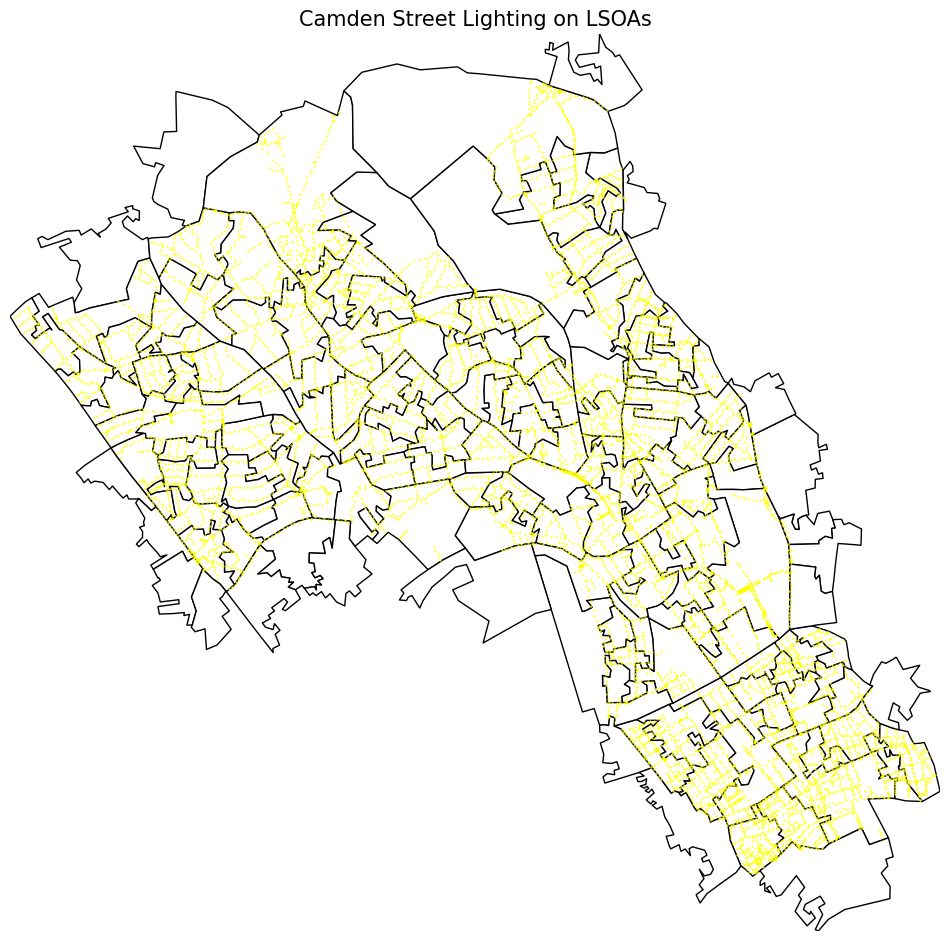

In [24]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point

def plot_street_lights_on_lsoas(street_lights_file, lsoa_boundaries_file):
    # Read the street lights CSV file
    try:
        street_lights_df = pd.read_csv(street_lights_file)
    except FileNotFoundError:
        print(f"Error: The file {street_lights_file} was not found.")
        return
    except pd.errors.ParserError:
        print(f"Error: The file {street_lights_file} could not be parsed.")
        return
    
    # Ensure the latitude and longitude columns are correct
    if 'Latitude' not in street_lights_df.columns or 'Longitude' not in street_lights_df.columns:
        print("Error: Latitude and/or Longitude columns not found in the CSV file.")
        return
    
    # Create a GeoDataFrame for street lights with CRS EPSG:4326 (assuming input is in WGS 84)
    street_lights_gdf = gpd.GeoDataFrame(
        street_lights_df, 
        geometry=[Point(xy) for xy in zip(street_lights_df['Longitude'], street_lights_df['Latitude'])],
        crs="EPSG:4326"  # WGS 84
    )
    
    # Transform the street lights GeoDataFrame to EPSG:27700 (British National Grid)
    street_lights_gdf = street_lights_gdf.to_crs(epsg=27700)
    
    # Read the LSOA boundary data
    try:
        lsoa_gdf = gpd.read_file(lsoa_boundaries_file)
    except FileNotFoundError:
        print(f"Error: The file {lsoa_boundaries_file} was not found.")
        return
    except IOError:
        print(f"Error: The file {lsoa_boundaries_file} could not be read.")
        return
    
    # Ensure the LSOA GeoDataFrame is in EPSG:27700 (British National Grid)
    if lsoa_gdf.crs != 'EPSG:27700':
        lsoa_gdf = lsoa_gdf.to_crs(epsg=27700)
    
    # Filter LSOA areas to only those that intersect with the street lights
    lsoa_gdf = lsoa_gdf[lsoa_gdf.geometry.intersects(street_lights_gdf.unary_union)]
    
    # Plot the filtered LSOA boundaries
    fig, ax = plt.subplots(figsize=(12, 12))
    lsoa_gdf.plot(ax=ax, color='white', edgecolor='black')
    
    # Overlay the street lights as sharp yellow points
    street_lights_gdf.plot(ax=ax, color='yellow', markersize=1, marker='.', linestyle='None')
    
    # Customize plot
    ax.set_title('Camden Street Lighting on LSOAs', fontdict={'fontsize': 15, 'fontweight': '3'})
    ax.set_axis_off()
    
    # Set the x and y limits to focus on the filtered LSOA areas
    minx, miny, maxx, maxy = lsoa_gdf.total_bounds
    ax.set_xlim(minx, maxx)
    ax.set_ylim(miny, maxy)
    
    # Show the plot
    plt.show()

# File paths to the CSV file and the LSOA boundary file
street_lights_file = r'C:\Users\Nineli.Lashkarashvil\SperryRail\Innovation\data_science\CPD\safe_route_finder\street_lighting\Camden_Street_Lighting_20250406.csv'
lsoa_boundaries_file = r"C:\Users\Nineli.Lashkarashvil\SperryRail\Innovation\data_science\CPD\safe_route_finder\lsoa_geojson_map.geojson"  # Update this to the path of your LSOA boundary file

# Call the function to plot the street lights on LSOAs
plot_street_lights_on_lsoas(street_lights_file, lsoa_boundaries_file)

In [5]:
lsoa_gdf.crs

<Projected CRS: EPSG:27700>
Name: OSGB36 / British National Grid
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: United Kingdom (UK) - offshore to boundary of UKCS within 49°45'N to 61°N and 9°W to 2°E; onshore Great Britain (England, Wales and Scotland). Isle of Man onshore.
- bounds: (-9.01, 49.75, 2.01, 61.01)
Coordinate Operation:
- name: British National Grid
- method: Transverse Mercator
Datum: Ordnance Survey of Great Britain 1936
- Ellipsoid: Airy 1830
- Prime Meridian: Greenwich

In [17]:
datetime.utcnow() + tz_offset_hours

TypeError: unsupported operand type(s) for +: 'datetime.datetime' and 'int'

In [8]:
def fetch_sunrise_sunset(lat, lng, date):
    url = f"https://api.sunrise-sunset.org/json?lat={lat}&lng={lng}&date={date}"
    response = requests.get(url)
    data = response.json()
    
    if data['status'] != 'OK':
        raise Exception("Error fetching data from Sunrise-Sunset API")
    
    sunrise_utc = data['results']['sunrise']
    sunset_utc = data['results']['sunset']
    
    return sunrise_utc, sunset_utc

lat = 36.7201600
lng = -4.4203400
current_time = datetime(2025, 4, 10, 7, 0)  # Example timestamp in UTC
timezone_offset_hours = 0  # UTC
fetch_sunrise_sunset(lat=lat, lng=lng, date=current_time.strftime('%Y-%m-%d'))

('5:48:47 AM', '6:49:02 PM')

LSOA CRS: EPSG:27700


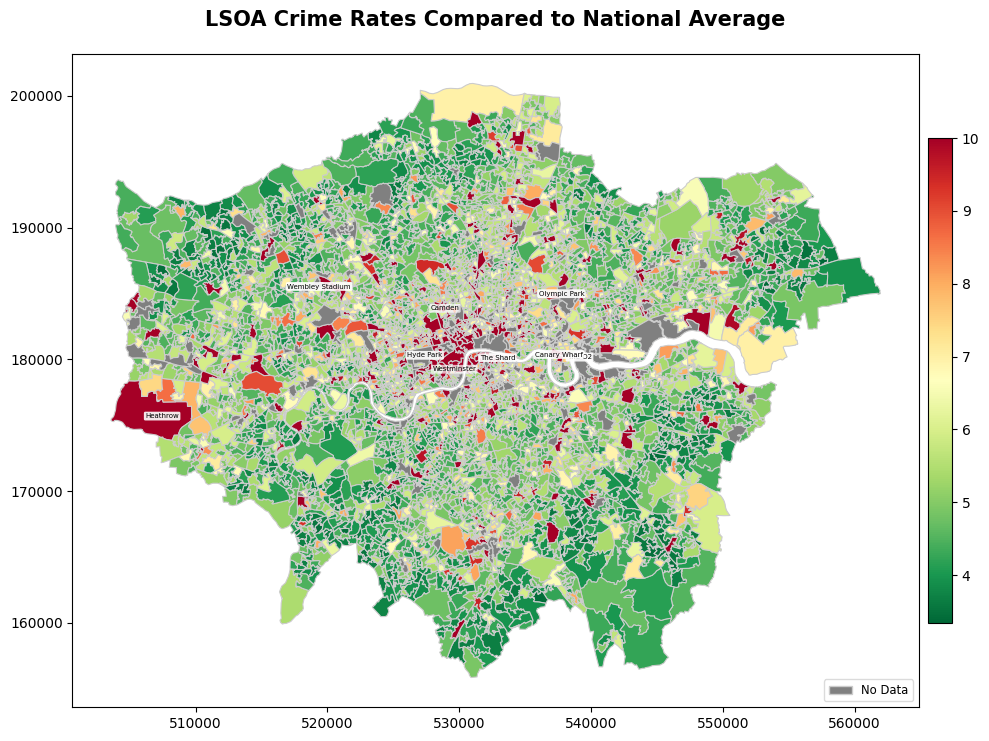

In [7]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from shapely.geometry import Point

# Load LSOA GeoDataFrame
lsoa_gdf = gpd.read_file(r"C:\Users\Nineli.Lashkarashvil\SperryRail\Innovation\data_science\CPD\safe_route_finder\lsoa_geojson_map.geojson")

# Load scores CSV
scores_df = pd.read_csv(r"C:\Users\Nineli.Lashkarashvil\SperryRail\Innovation\data_science\CPD\safe_route_finder\output_safety_scores.csv")

# Ensure the LSOA code columns have the same name
lsoa_gdf = lsoa_gdf.rename(columns={'LSOA11CD': 'LSOA Code'})

# Merge GeoDataFrame with the scores DataFrame
merged_gdf = lsoa_gdf.merge(scores_df, on='LSOA Code', how='left')

# Check the coordinate system of your LSOA data
print(f"LSOA CRS: {lsoa_gdf.crs}")

# Create figure and plot
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

# Plot the data
plot = merged_gdf.plot(
    column='routing_score', 
    cmap='RdYlGn_r', 
    linewidth=0.8, 
    ax=ax, 
    edgecolor='0.8', 
    legend=True,
    legend_kwds={
        'shrink': 0.5,
        'pad': 0.01,
        'fraction': 0.046,
        'aspect': 20
    }
)

# Plot areas with no data in gray
merged_gdf[merged_gdf['routing_score'].isna()].plot(
    color='gray', 
    ax=ax, 
    edgecolor='0.8',
    linewidth=0.8
)

# Create a custom legend for the "No Data" category
no_data_patch = Patch(facecolor='gray', edgecolor='0.8', label='No Data')
ax.legend(
    handles=[no_data_patch],
    loc='lower right',
    frameon=True,
    framealpha=0.7,
    fontsize='small'
)

ax.set_title(
    'LSOA Crime Rates Compared to National Average', 
    fontdict={
        'fontsize': 15,
        'fontweight': 'bold',
        'fontfamily': 'sans-serif',
        'color': 'black'
    },
    pad=20
)

# London borough/district names (WGS84 coordinates)
london_areas = {
    'Westminster': [-0.1340, 51.4973],
    'Camden': [-0.1426, 51.5390],
    # ... other areas ...
}

# Convert WGS84 coordinates to the same CRS as your LSOA data
def convert_coordinates(locations, target_crs):
    converted_locations = {}
    for name, coords in locations.items():
        # Create a GeoDataFrame with the point
        point_gdf = gpd.GeoDataFrame(
            {'name': [name]}, 
            geometry=[Point(coords[0], coords[1])],
            crs="EPSG:4326"  # WGS84
        )
        # Transform to target CRS
        point_gdf = point_gdf.to_crs(target_crs)
        # Store the transformed coordinates
        converted_locations[name] = [point_gdf.geometry.iloc[0].x, point_gdf.geometry.iloc[0].y]
    return converted_locations

# Convert borough and landmark coordinates to match LSOA CRS
converted_areas = convert_coordinates(london_areas, lsoa_gdf.crs)
converted_landmarks = convert_coordinates(landmarks, lsoa_gdf.crs)

# Function to add labels
def add_labels(locations, font_size=7, color='black', alpha=0.8):
    # Get current axis limits to determine map zoom level
    x_range = ax.get_xlim()[1] - ax.get_xlim()[0]
    
    # Adjust font size based on zoom level
    adjusted_size = font_size * (0.2 / x_range) * 10
    adjusted_size = min(max(adjusted_size, 5), 12)  # Keep size between 5 and 12
    
    # Add labels for each location
    for name, coords in locations.items():
        # Only add if within current view
        if (ax.get_xlim()[0] <= coords[0] <= ax.get_xlim()[1] and 
            ax.get_ylim()[0] <= coords[1] <= ax.get_ylim()[1]):
            ax.text(
                coords[0], coords[1], 
                name, 
                fontsize=adjusted_size,
                ha='center',
                va='center',
                color=color,
                bbox=dict(
                    facecolor='white', 
                    alpha=alpha, 
                    edgecolor='none', 
                    boxstyle='round,pad=0.2'
                ),
                zorder=5  # Ensure text appears on top
            )

# Add borough names with smaller font
add_labels(converted_areas, font_size=7, alpha=0.7)

# Add landmark names with slightly larger font
add_labels(converted_landmarks, font_size=8, alpha=0.9)

plt.tight_layout()
plt.show()

In [ ]:
import geopandas as gpd
import pandas as pd
import folium
from folium.plugins import Fullscreen, Search, MeasureControl
import branca.colormap as cm

# Load LSOA GeoDataFrame
lsoa_gdf = gpd.read_file(r"C:\Users\Nineli.Lashkarashvil\SperryRail\Innovation\data_science\CPD\safe_route_finder\lsoa_geojson_map.geojson")

# Load scores CSV
scores_df = pd.read_csv(r"C:\Users\Nineli.Lashkarashvil\SperryRail\Innovation\data_science\CPD\safe_route_finder\output_safety_scores.csv")

# Ensure the LSOA code columns have the same name
lsoa_gdf = lsoa_gdf.rename(columns={'LSOA11CD': 'LSOA Code'})

# Merge GeoDataFrame with the scores DataFrame
merged_gdf = lsoa_gdf.merge(scores_df, on='LSOA Code', how='left')

# Convert to WGS84 (EPSG:4326) for Folium
merged_gdf_wgs84 = merged_gdf.to_crs(epsg=4326)

# Create a Folium map centered on London
m = folium.Map(
    location=[51.5074, -0.1278],  # London center
    zoom_start=10,
    tiles='CartoDB positron',  # Light background
    control_scale=True  # Add scale
)

# Add fullscreen button
Fullscreen().add_to(m)

# Create a colormap for the safety scores
valid_scores = merged_gdf_wgs84['routing_score'].dropna()
if len(valid_scores) > 0:
    vmin = valid_scores.min()
    vmax = valid_scores.max()
else:
    vmin, vmax = 0, 1  # Default if no valid scores

# Create a colormap - RdYlGn_r is red-yellow-green reversed (red is bad, green is good)
colormap = cm.LinearColormap(
    colors=['darkgreen', 'green', 'yellowgreen', 'yellow', 'orange', 'orangered', 'red', 'darkred'],
    vmin=vmin, 
    vmax=vmax
)
colormap.caption = 'Crime Rate vs National Average'
colormap.add_to(m)

# Function to style the GeoJSON features
def style_function(feature):
    score = feature['properties']['routing_score']
    if pd.isna(score):
        return {
            'fillColor': 'gray',
            'color': 'black',
            'weight': 0.5,
            'fillOpacity': 0.7
        }
    else:
        return {
            'fillColor': colormap(score),
            'color': 'black',
            'weight': 0.5,
            'fillOpacity': 0.7
        }

# Function for hover styling
def highlight_function(feature):
    return {
        'weight': 3,
        'fillOpacity': 0.9,
        'color': '#000000'
    }

# Add the LSOA GeoJSON layer with styling and tooltips showing LSOA names
folium.GeoJson(
    merged_gdf_wgs84,
    style_function=style_function,
    highlight_function=highlight_function,
    tooltip=folium.GeoJsonTooltip(
        fields=['LSOA11NM', 'routing_score'],  # Use LSOA11NM for the name
        aliases=['Area:', 'Safety Score:'],
        localize=True,
        sticky=False,
        labels=True,
        style="""
            background-color: #F0EFEF;
            border: 2px solid black;
            border-radius: 3px;
            box-shadow: 3px;
            font-size: 12px;
            padding: 5px;
        """
    ),
    popup=folium.GeoJsonPopup(
        fields=['LSOA11NM', 'LSOA Code', 'routing_score'],
        aliases=['Area Name:', 'LSOA Code:', 'Safety Score:'],
        localize=True,
        labels=True,
        style="""
            background-color: white;
            font-size: 14px;
            padding: 10px;
        """
    ),
    name="LSOA Safety Scores",
    overlay=True,
    control=True,
).add_to(m)

# Define London areas and landmarks
london_areas = {
    'Westminster': [-0.1340, 51.4973],
    'Camden': [-0.1426, 51.5390],
    'Islington': [-0.1069, 51.5416],
    'Hackney': [-0.0575, 51.5450],
    'Tower Hamlets': [-0.0213, 51.5150],
    'Southwark': [-0.0765, 51.5035],
    'Lambeth': [-0.1196, 51.4961],
    'Kensington & Chelsea': [-0.1762, 51.5020],
    'City of London': [-0.0923, 51.5155]
}

landmarks = {
    'The O2': [0.0031, 51.5033],
    'Hyde Park': [-0.1657, 51.5073],
    'Olympic Park': [-0.0147, 51.5469],
    'Canary Wharf': [-0.0197, 51.5055],
    'The Shard': [-0.0865, 51.5045],
    'Trafalgar Square': [-0.1281, 51.5080],
    'Buckingham Palace': [-0.1419, 51.5014],
    'London Bridge': [-0.0883, 51.5080],
    'King\'s Cross': [-0.1233, 51.5308],
    'Waterloo': [-0.1145, 51.5031]
}

# Create feature groups for organization
borough_group = folium.FeatureGroup(name="London Boroughs", show=True)
landmark_group = folium.FeatureGroup(name="Landmarks", show=True)

# Add borough markers
for name, coords in london_areas.items():
    folium.Marker(
        location=[coords[1], coords[0]],
        tooltip=name,
        icon=folium.Icon(icon='home', prefix='fa', color='blue'),
        popup=name
    ).add_to(borough_group)

# Add landmark markers
for name, coords in landmarks.items():
    folium.Marker(
        location=[coords[1], coords[0]],
        tooltip=name,
        icon=folium.Icon(icon='map-marker', prefix='fa', color='red'),
        popup=name
    ).add_to(landmark_group)

# Add the feature groups to the map
borough_group.add_to(m)
landmark_group.add_to(m)

# Add layer control
folium.LayerControl().add_to(m)

# Add title
title_html = '''
<div style="position: fixed; 
     top: 10px; left: 50%; transform: translateX(-50%);
     z-index:9999; font-size:18px; font-weight: bold;
     background-color: white; padding: 10px; border-radius: 5px;
     box-shadow: 0 0 5px rgba(0,0,0,0.3);">
     LSOA Crime Rates Compared to National Average
</div>
'''
m.get_root().html.add_child(folium.Element(title_html))

# Add a custom legend for "No Data"
legend_html = '''
<div style="position: fixed; 
     bottom: 50px; left:     bottom: 50px; left: 50px; 
     z-index:9999; font-size:12px;
     background-color: white; padding: 10px; border-radius: 5px;
     box-shadow: 0 0 5px rgba(0,0,0,0.3);">

     <p><b>Legend</b></p>
     <p><i class="fa fa-square" style="color:gray"></i> No Data</p>
     <p><i class="fa fa-home" style="color:blue"></i> Borough</p>
     <p><i class="fa fa-map-marker" style="color:red"></i> Landmark</p>
</div>
'''
m.get_root().html.add_child(folium.Element(legend_html))

# Add search functionality with all locations
from folium.plugins import Search
from shapely.geometry import Point

# Combine all locations for search
all_locations = {**london_areas, **landmarks}
location_gdf = gpd.GeoDataFrame(
    index=range(len(all_locations)),
    crs="EPSG:4326",
    geometry=[Point(coords[0], coords[1]) for coords in all_locations.values()]
)
location_gdf['name'] = list(all_locations.keys())
location_gdf['type'] = ['Borough' if name in london_areas else 'Landmark' for name in all_locations.keys()]

# Convert to GeoJSON for search
location_geojson = location_gdf.to_json()
search = Search(
    layer=folium.GeoJson(location_geojson),
    geom_type='Point',
    placeholder='Search for a location',
    collapsed=True,
    search_label='name',
    search_zoom=15
)
m.add_child(search)

# Add measure tool for distance calculations
m.add_child(MeasureControl(position='topright', primary_length_unit='kilometers'))

# Save to HTML
output_path = r"C:\Users\Nineli.Lashkarashvil\SperryRail\Innovation\data_science\CPD\safe_route_finder\london_crime_map_interactive.html"
m.save(output_path)

print(f"Interactive map saved to: {output_path}")

Interactive map saved to: C:\Users\Nineli.Lashkarashvil\SperryRail\Innovation\data_science\CPD\safe_route_finder\london_crime_map_interactive.html


: 

In [ ]:
lsoa_gdf.columns

Index(['LSOA Code', 'LSOA11NM', 'MSOA11CD', 'MSOA11NM', 'LAD11CD', 'LAD11NM',
       'RGN11CD', 'RGN11NM', 'UsualRes', 'HholdRes', 'ComEstRes', 'PopDen',
       'Hholds', 'AvHholdSz', 'geometry'],
      dtype='object')